In [41]:
from pathlib import Path
import pandas as pd
import numpy as np
import ast

# =============================================================================
# Path Configuration
# =============================================================================
DATA_DIR = Path('..') / 'data'
RAW_BASE_DIR = DATA_DIR / 'raw'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'
OUT_DIR = RAW_BASE_DIR / 'mt1cfl_2526'
RAW_DIR = OUT_DIR / 'raw_by_match'

# =============================================================================
# Load Processed Data
# =============================================================================
print("📂 Loading processed data...")

# Load player and team metadata
players_meta = pd.read_csv(PROCESSED_DATA_DIR / 'players_metadata.csv')
teams_meta = pd.read_csv(PROCESSED_DATA_DIR / 'teams_metadata.csv')
matches_meta = pd.read_csv(PROCESSED_DATA_DIR / 'matches_metadata.csv')
player_stats = pd.read_csv(PROCESSED_DATA_DIR / 'match_player_statistics.csv')

# Create team name mapping
team_name_map = dict(zip(teams_meta['team_id'], teams_meta['team_name']))

print(f"✅ Loaded {len(players_meta)} players, {len(teams_meta)} teams, {len(matches_meta)} matches")

# =============================================================================
# Load Shot Data with xG
# =============================================================================
print("\n📊 Loading shot data for xG analysis...")

shots_all_list = []
for match_dir in RAW_DIR.glob('*'):
    shots_file = match_dir / 'match_shots.csv'
    if shots_file.exists():
        try:
            df = pd.read_csv(shots_file)
            df['match_id'] = int(match_dir.name)
            shots_all_list.append(df)
        except Exception as e:
            print(f"⚠️ Error loading {shots_file}: {e}")

if not shots_all_list:
    raise RuntimeError(f"No shots data found in {RAW_DIR}")

shots_all_df = pd.concat(shots_all_list, ignore_index=True)
print(f"✅ Loaded {len(shots_all_df)} shots from {len(shots_all_list)} matches")

# =============================================================================
# Process Shot Data
# =============================================================================

# Extract goal flag from shotType
shots_all_df['isGoal'] = (shots_all_df['shotType'] == 'goal').astype(int)

# Extract player_id from player column (handle both string and dict formats)
shots_all_df['player_id'] = shots_all_df['player'].apply(
    lambda p: ast.literal_eval(p).get('id') if isinstance(p, str) else (p.get('id') if isinstance(p, dict) else None)
)

# Use processed match_player_statistics for player-team mapping (includes team_name)
player_team_map = player_stats[['match_id', 'player_id', 'team_id', 'team_name']].drop_duplicates()

# Merge shots with team information
shots_all_df = shots_all_df.merge(
    player_team_map,
    on=['match_id', 'player_id'],
    how='left'
)

print(f"✅ Mapped {shots_all_df['team_id'].notna().sum()} shots to teams")

# =============================================================================
# Aggregate Player xG Statistics
# =============================================================================

# Group by player and team (to handle transfers correctly)
player_xg_by_team = (
    shots_all_df
    .groupby(['player_id', 'team_id'], as_index=False)
    .agg(
        Goals=('isGoal', 'sum'), 
        xG=('xg', 'sum'),
        team_name=('team_name', 'first')  # Take first team_name for this team_id
    )
)

# For each player, use the team they had the most xG with
player_xg = (
    player_xg_by_team
    .sort_values('xG', ascending=False)
    .groupby('player_id', as_index=False)
    .first()
)

# Add player names
player_xg = player_xg.merge(
    players_meta[['id', 'name']],
    left_on='player_id',
    right_on='id',
    how='left'
).drop(columns=['id'])

# Rename Team column for consistency
player_xg = player_xg.rename(columns={'team_name': 'Team'})
player_xg['Diff'] = player_xg['Goals'] - player_xg['xG']

# =============================================================================
# Identify Top Performers
# =============================================================================

MIN_XG = 1.0
TOP_N = 3

# Filter to players with sufficient xG
goals_xg_plot = player_xg[player_xg['xG'] >= MIN_XG].copy()

# Default styling
goals_xg_plot['Color'] = '#555555'
goals_xg_plot['Size'] = 1.0

# Find top over- and under-performers
top_outperformers = goals_xg_plot.nlargest(TOP_N, 'Diff').copy()
top_underperformers = goals_xg_plot.nsmallest(TOP_N, 'Diff').copy()

# Highlight in plot
goals_xg_plot.loc[top_outperformers.index, 'Color'] = 'green'
goals_xg_plot.loc[top_underperformers.index, 'Color'] = 'red'
goals_xg_plot.loc[top_outperformers.index.union(top_underperformers.index), 'Size'] = 3.0

# =============================================================================
# Display Results
# =============================================================================

print('\n✅ Analysis complete!')
print(f'\n🎯 Top {TOP_N} Outperformers (Goals > xG):')
display(top_outperformers[['name', 'Team', 'Goals', 'xG', 'Diff']].round(2))

print(f'\n📉 Top {TOP_N} Underperformers (Goals < xG):')
display(top_underperformers[['name', 'Team', 'Goals', 'xG', 'Diff']].round(2))

📂 Loading processed data...
✅ Loaded 285 players, 10 teams, 95 matches

📊 Loading shot data for xG analysis...
⚠️ Error loading ..\data\raw\mt1cfl_2526\raw_by_match\14147344\match_shots.csv: No columns to parse from file
⚠️ Error loading ..\data\raw\mt1cfl_2526\raw_by_match\14952691\match_shots.csv: No columns to parse from file
✅ Loaded 2022 shots from 95 matches
✅ Mapped 2022 shots to teams

✅ Analysis complete!

🎯 Top 3 Outperformers (Goals > xG):


,name,Team,Goals,xG,Diff
44,Armin Bošnjak,FK Arsenal Tivat,5,1.49,3.51
103,Žarko Popović,OFK Petrovac,5,2.31,2.69
130,Balša Radusinović,FK Dečić Tuzi,4,1.53,2.47



📉 Top 3 Underperformers (Goals < xG):


,name,Team,Goals,xG,Diff
66,Marko Milickovic,FK Budućnost Podgorica,0,3.14,-3.14
102,Balša Tošković,FK Sutjeska Nikšić,2,4.18,-2.18
77,Petar Vukčević,FK Mornar Bar,0,1.90,-1.90


# Goals vs Expected Goals (xG) Analysis

This notebook analyzes player performance by comparing actual goals scored vs expected goals (xG) from shot data.

**Data Sources:**
- Shot data from `match_shots.csv` files (includes xG values)
- Player metadata from `players_metadata.csv`

**Analysis:**
- Identifies top **outperformers** (players scoring more than expected)
- Identifies top **underperformers** (players scoring less than expected)
- Creates visualization comparing goals vs xG

✅ Loaded 10 team logos
✅ Loaded 209 player photos

✅ Figure saved to: ..\outputs\figures\polutka_lab_goals_vs_xg_post.png


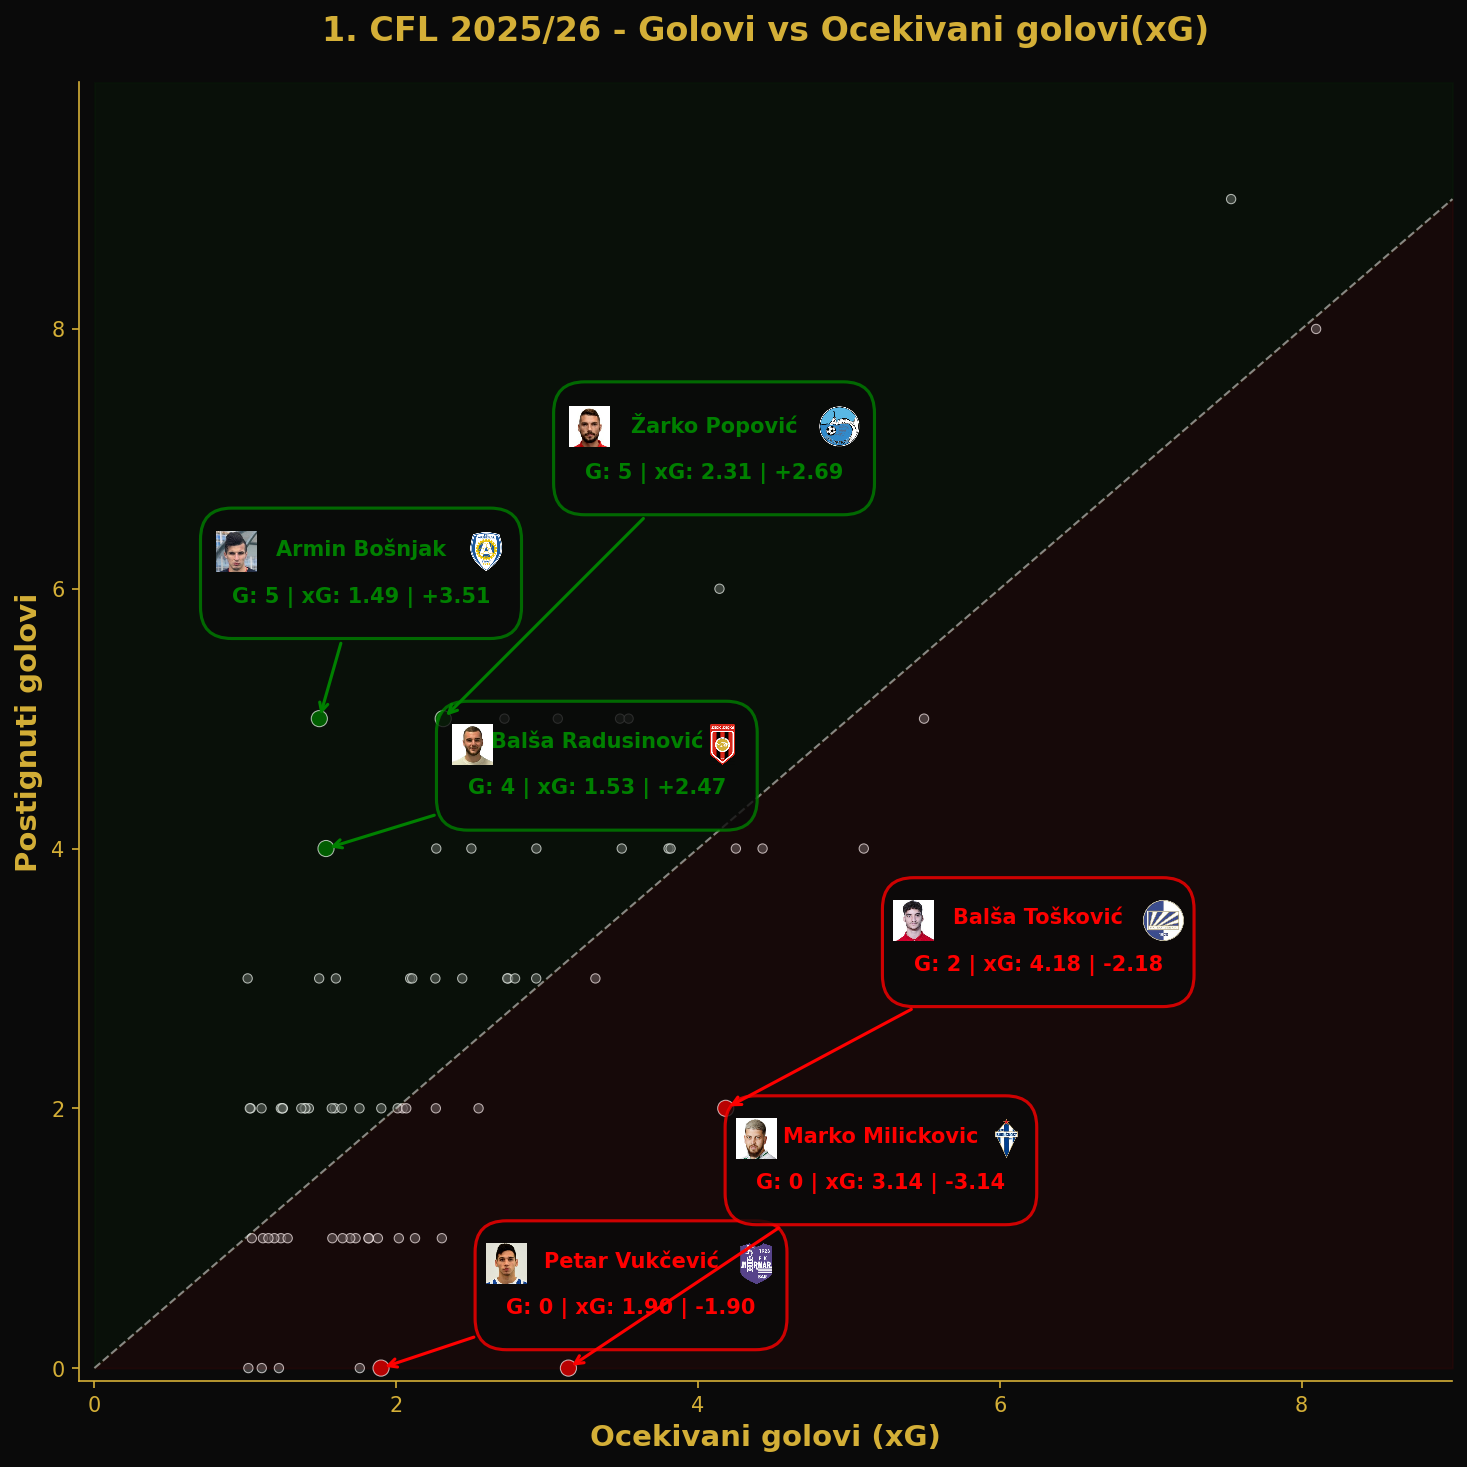

In [42]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from PIL import Image, ImageDraw, ImageFont
import io
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

# Create Instagram post (1080x1350 portrait)
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)

# Set dark background
ax.set_facecolor('#0a0a0a')
fig.patch.set_facecolor('#0a0a0a')

# Plot goals vs xG
scatter = ax.scatter(goals_xg_plot['xG'], goals_xg_plot['Goals'], 
                     c=goals_xg_plot['Color'], s=goals_xg_plot['Size']*20, 
                     alpha=0.7, edgecolors='white', linewidth=0.5)

# Add diagonal reference line
max_val = max(goals_xg_plot['xG'].max(), goals_xg_plot['Goals'].max())
ax.plot([0, max_val], [0, max_val], 'w--', alpha=0.5, linewidth=1)

# Set axis limits with padding
y_padding = max_val * 0.1
ax.set_ylim(bottom=-0.1, top=max_val + y_padding)
ax.set_xlim(left=-0.1, right=max_val)

# Shade areas
x_fill = np.linspace(0, max_val, 100)
ax.fill_between(x_fill, x_fill, max_val + y_padding, color='green', alpha=0.05, label='Outperforming xG')
ax.fill_between(x_fill, 0, x_fill, color='red', alpha=0.05, label='Underperforming xG')

# Precompute per-goal offsets so players with same Goals get slightly different label positions
top_out_sorted = top_outperformers.sort_values(['Goals', 'xG']).copy()
top_out_sorted['offset_idx'] = top_out_sorted.groupby('Goals').cumcount()

top_under_sorted = top_underperformers.sort_values(['Goals', 'xG']).copy()
top_under_sorted['offset_idx'] = top_under_sorted.groupby('Goals').cumcount()

# Load team logos
team_logos = {}
logos_dir = PROCESSED_DATA_DIR / 'team_logos'
if logos_dir.exists():
    for logo_file in logos_dir.glob('*.png'):
        try:
            tid = int(logo_file.stem)
            team_logos[tid] = mpimg.imread(logo_file)
        except Exception as e:
            print(f"⚠️ Could not load logo {logo_file}: {e}")

print(f"✅ Loaded {len(team_logos)} team logos")

# Load player photos
player_photos = {}
photos_dir = PROCESSED_DATA_DIR / 'player_photos'
if photos_dir.exists():
    for photo_file in photos_dir.glob('*.png'):
        try:
            pid = int(photo_file.stem)
            player_photos[pid] = mpimg.imread(photo_file)
        except Exception as e:
            print(f"⚠️ Could not load photo {photo_file}: {e}")

print(f"✅ Loaded {len(player_photos)} player photos")

# Annotate top outperformers (green) with player photos on the left and team logos on the right
for _, row in top_out_sorted.iterrows():
    # Custom positioning for specific players
    if 'Armin' in row['name'] and 'Bo' in row['name']:
        # Armin Bošnjak - move to the right
        dx = 20
        dy = 70
    elif 'Bal' in row['name'] and 'Radu' in row['name']:
        # Balša Radusinović - move significantly to the right
        dx = 130
        dy = 40
    elif 'arko' in row['name'] and 'Pop' in row['name']:
        # Žarko Popović - move more to the top right
        dx = 130
        dy = 130
    else:
        # Default positioning for other outperformers
        dx = 60
        dy = 35 + row['offset_idx'] * 50
    
    # Add text annotation with name on top line, extra space, then stats on bottom line
    stats_text = f"{row['name']}\n\nG: {int(row['Goals'])} | xG: {row['xG']:.2f} | +{row['Diff']:.2f}"
    ann = ax.annotate(
        stats_text, (row['xG'], row['Goals']),
        xytext=(dx, dy), textcoords='offset points',
        ha='center', va='center',
        fontsize=10, color='green', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
        bbox=dict(boxstyle='round,pad=1.5', facecolor='#0a0a0a', edgecolor='green', alpha=0.8, linewidth=1.5)
    )
    
    # Add player photo to the left of the name (top row of the box)
    if pd.notna(row.get('player_id')):
        try:
            pid = int(row['player_id'])
        except (TypeError, ValueError):
            pid = None
        if pid is not None and pid in player_photos:
            photo = player_photos[pid]
            photo_imagebox = OffsetImage(photo, zoom=0.13)
            # Position closer to the name, aligned with the name (top line)
            photo_ab = AnnotationBbox(
                photo_imagebox, (row['xG'], row['Goals']),
                xybox=(dx - 60, dy + 10), boxcoords='offset points',
                frameon=False, pad=0
            )
            ax.add_artist(photo_ab)
    
    # Add team logo to the right of the name (top row of the box)
    if pd.notna(row.get('team_id')) and int(row['team_id']) in team_logos:
        logo = team_logos[int(row['team_id'])]
        logo_imagebox = OffsetImage(logo, zoom=0.13)
        # Position closer to the name, aligned with the name (top line)
        logo_ab = AnnotationBbox(
            logo_imagebox, (row['xG'], row['Goals']),
            xybox=(dx + 60, dy + 10), boxcoords='offset points',
            frameon=False, pad=0
        )
        ax.add_artist(logo_ab)

# Annotate top underperformers (red) with player photos on the left and team logos on the right
for _, row in top_under_sorted.iterrows():
    # Custom positioning for specific players
    if 'Bal' in row['name'] and 'To' in row['name']:
        # Balša Tošković - move much further to make arrow longer and more visible
        dx = 150
        dy = 80
    elif 'Marko' in row['name'] and 'Mil' in row['name']:
        # Marko Milickovic - move more to the right and slightly up
        dx = 150
        dy = 100
    elif 'Petar' in row['name'] and 'Vuk' in row['name']:
        # Petar Vukčević - move to the right
        dx = 120
        dy = 40
    else:
        # Default positioning for other underperformers
        dx = 60
        dy = 35 + row['offset_idx'] * 50
    
    # Add text annotation with name on top line, extra space, then stats on bottom line
    stats_text = f"{row['name']}\n\nG: {int(row['Goals'])} | xG: {row['xG']:.2f} | {row['Diff']:.2f}"
    ann = ax.annotate(
        stats_text, (row['xG'], row['Goals']),
        xytext=(dx, dy), textcoords='offset points',
        ha='center', va='center',
        fontsize=10, color='red', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
        bbox=dict(boxstyle='round,pad=1.5', facecolor='#0a0a0a', edgecolor='red', alpha=0.8, linewidth=1.5)
    )
    
    # Add player photo to the left of the name (top row of the box)
    if pd.notna(row.get('player_id')):
        try:
            pid = int(row['player_id'])
        except (TypeError, ValueError):
            pid = None
        if pid is not None and pid in player_photos:
            photo = player_photos[pid]
            photo_imagebox = OffsetImage(photo, zoom=0.13)
            # Position closer to the name, aligned with the name (top line)
            photo_ab = AnnotationBbox(
                photo_imagebox, (row['xG'], row['Goals']),
                xybox=(dx - 60, dy + 10), boxcoords='offset points',
                frameon=False, pad=0
            )
            ax.add_artist(photo_ab)
    
    # Add team logo to the right of the name (top row of the box)
    if pd.notna(row.get('team_id')) and int(row['team_id']) in team_logos:
        logo = team_logos[int(row['team_id'])]
        logo_imagebox = OffsetImage(logo, zoom=0.13)
        # Position closer to the name, aligned with the name (top line)
        logo_ab = AnnotationBbox(
            logo_imagebox, (row['xG'], row['Goals']),
            xybox=(dx + 60, dy + 10), boxcoords='offset points',
            frameon=False, pad=0
        )
        ax.add_artist(logo_ab)

# Styling
ax.set_xlabel('Ocekivani golovi (xG)', fontsize=14, color='#d4af37', fontweight='bold')
ax.set_ylabel('Postignuti golovi', fontsize=14, color='#d4af37', fontweight='bold')
ax.grid(False)
ax.spines['bottom'].set_color('#d4af37')
ax.spines['left'].set_color('#d4af37')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='#d4af37', labelsize=10)

# Add title
ax.set_title('1. CFL 2025/26 - Golovi vs Ocekivani golovi(xG)', 
             fontsize=16, color='#d4af37', fontweight='bold', pad=20)

plt.tight_layout(pad=1.5)

# Save figure under outputs/figures/
figures_dir = Path('..') / 'outputs' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
output_path = figures_dir / 'polutka_lab_goals_vs_xg_post.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', 
            facecolor='#0a0a0a', edgecolor='none')
print(f'\n✅ Figure saved to: {output_path}')
plt.show()

In [43]:
# League-wide xG vs Goals Analysis
print('='*60)
print('1. CFL 2025/26 - League-wide Goals vs Expected Goals (xG)')
print('='*60)

# Calculate total xG and goals across the entire league
total_xg = shots_all_df['xg'].sum()
total_goals = shots_all_df['isGoal'].sum()
difference = total_goals - total_xg
percentage_diff = (difference / total_xg) * 100

print(f'\n📊 Overall League Statistics:')
print(f'   Total Expected Goals (xG): {total_xg:.2f}')
print(f'   Total Actual Goals:        {total_goals}')
print(f'   Difference:                {difference:+.2f}')
print(f'   Percentage Difference:     {percentage_diff:+.2f}%')

if difference > 0:
    print(f'\n✅ The league is OVERPERFORMING xG by {abs(difference):.2f} goals ({abs(percentage_diff):.2f}%)')
elif difference < 0:
    print(f'\n📉 The league is UNDERPERFORMING xG by {abs(difference):.2f} goals ({abs(percentage_diff):.2f}%)')
else:
    print(f'\n🎯 The league is performing exactly at xG expectations')

# Calculate conversion rate
total_shots = len(shots_all_df)
actual_conversion = (total_goals / total_shots) * 100
expected_conversion = (total_xg / total_shots) * 100

print(f'\n🎯 Conversion Rates:')
print(f'   Expected Conversion Rate: {expected_conversion:.2f}%')
print(f'   Actual Conversion Rate:   {actual_conversion:.2f}%')

print('='*60)

1. CFL 2025/26 - League-wide Goals vs Expected Goals (xG)

📊 Overall League Statistics:
   Total Expected Goals (xG): 220.79
   Total Actual Goals:        238
   Difference:                +17.21
   Percentage Difference:     +7.79%

✅ The league is OVERPERFORMING xG by 17.21 goals (7.79%)

🎯 Conversion Rates:
   Expected Conversion Rate: 10.92%
   Actual Conversion Rate:   11.77%


In [44]:
# =============================================================================
# Team-level xG vs Goals Analysis
# =============================================================================

print('\n' + '='*60)
print('Team Performance Analysis - Goals vs Expected Goals (xG)')
print('='*60)

# Aggregate shots by team (group by team_id only to avoid duplicates)
team_stats = (
    shots_all_df
    .groupby('team_id')
    .agg(
        xG=('xg', 'sum'),
        Goals=('isGoal', 'sum'),
        Shots=('xg', 'count')
    )
    .reset_index()
)

# Add canonical team names from teams_meta
team_stats['Team'] = team_stats['team_id'].map(team_name_map)

# Load league standings for ordering
standings_path = PROCESSED_DATA_DIR / 'league_standings.csv'
if standings_path.exists():
    standings_df = pd.read_csv(standings_path, usecols=['team_id', 'position'])
    team_stats = team_stats.merge(standings_df, on='team_id', how='left')
    team_stats = team_stats.rename(columns={'position': 'Position'})
else:
    print(f"⚠️ Standings file not found. Using performance-based ordering.")
    team_stats['Position'] = np.nan

# Calculate performance metrics
team_stats['Diff'] = team_stats['Goals'] - team_stats['xG']
team_stats['Diff_Pct'] = (team_stats['Diff'] / team_stats['xG']) * 100
team_stats['Conversion_Rate'] = (team_stats['Goals'] / team_stats['Shots']) * 100
team_stats['Expected_Conversion'] = (team_stats['xG'] / team_stats['Shots']) * 100

# Sort by performance difference
team_stats_by_diff = team_stats.sort_values('Diff', ascending=False).reset_index(drop=True)
team_stats_by_position = team_stats.sort_values('Position', na_position='last').reset_index(drop=True)
team_stats_sorted = team_stats_by_diff.copy()

# Display team statistics
print(f'\n📊 Team Statistics (sorted by performance vs xG):')
print('-'*60)

for _, row in team_stats_sorted.iterrows():
    team_name = row['Team'] if pd.notna(row['Team']) else f"Team {int(row['team_id'])}"
    perf_indicator = '✅' if row['Diff'] > 0 else ('📉' if row['Diff'] < 0 else '🎯')
    
    print(f"\n{perf_indicator} {team_name}")
    print(f"   Goals: {int(row['Goals'])} | xG: {row['xG']:.2f} | Diff: {row['Diff']:+.2f} ({row['Diff_Pct']:+.1f}%)")
    print(f"   Conversion: {row['Conversion_Rate']:.2f}% (Expected: {row['Expected_Conversion']:.2f}%)")

# Summary
top_overperformer = team_stats_sorted.iloc[0]
top_underperformer = team_stats_sorted.iloc[-1]

print('\n' + '='*60)
print(f'🏆 Best Overperformer: {top_overperformer["Team"]} (+{top_overperformer["Diff"]:.2f} goals, +{top_overperformer["Diff_Pct"]:.1f}%)')
print(f'📉 Biggest Underperformer: {top_underperformer["Team"]} ({top_underperformer["Diff"]:.2f} goals, {top_underperformer["Diff_Pct"]:.1f}%)')
print('='*60)

# Create summary table
team_summary = team_stats_sorted[['Team', 'Goals', 'xG', 'Diff', 'Diff_Pct', 'Conversion_Rate']].copy()
team_summary.columns = ['Team', 'Goals', 'xG', 'Difference', 'Diff %', 'Conv %']
team_summary = team_summary.round(2)

print('\n📋 Complete Team Summary Table:')
display(team_summary)


Team Performance Analysis - Goals vs Expected Goals (xG)

📊 Team Statistics (sorted by performance vs xG):
------------------------------------------------------------

✅ FK Dečić Tuzi
   Goals: 28 | xG: 20.33 | Diff: +7.67 (+37.7%)
   Conversion: 16.97% (Expected: 12.32%)

✅ OFK Petrovac
   Goals: 27 | xG: 21.20 | Diff: +5.80 (+27.3%)
   Conversion: 11.20% (Expected: 8.80%)

✅ FK Sutjeska Nikšić
   Goals: 31 | xG: 27.30 | Diff: +3.70 (+13.6%)
   Conversion: 13.08% (Expected: 11.52%)

✅ FK Arsenal Tivat
   Goals: 16 | xG: 12.85 | Diff: +3.15 (+24.5%)
   Conversion: 10.81% (Expected: 8.68%)

✅ FK Jezero
   Goals: 26 | xG: 23.90 | Diff: +2.10 (+8.8%)
   Conversion: 11.93% (Expected: 10.96%)

✅ FK Bokelj Kotor
   Goals: 22 | xG: 20.17 | Diff: +1.83 (+9.0%)
   Conversion: 13.66% (Expected: 12.53%)

✅ Mladost DG
   Goals: 29 | xG: 27.97 | Diff: +1.03 (+3.7%)
   Conversion: 13.30% (Expected: 12.83%)

📉 FK Budućnost Podgorica
   Goals: 23 | xG: 23.27 | Diff: -0.27 (-1.2%)
   Conversion: 10.5

,Team,Goals,xG,Difference,Diff %,Conv %
0,FK Dečić Tuzi,28,20.33,7.67,37.75,16.97
1,OFK Petrovac,27,21.20,5.80,27.34,11.20
2,FK Sutjeska Nikšić,31,27.30,3.70,13.55,13.08
3,FK Arsenal Tivat,16,12.85,3.15,24.48,10.81
4,FK Jezero,26,23.90,2.10,8.80,11.93
5,FK Bokelj Kotor,22,20.17,1.83,9.05,13.66
6,Mladost DG,29,27.97,1.03,3.70,13.30
7,FK Budućnost Podgorica,23,23.27,-0.27,-1.15,10.55
8,FK Mornar Bar,25,27.14,-2.14,-7.90,11.47
9,FK Jedinstvo Bijelo Polje,11,16.66,-5.66,-33.98,5.73


✅ Loaded 10 team logos
✅ Figure 1 saved to: ..\outputs\figures\team_goals_vs_xg_comparison.png


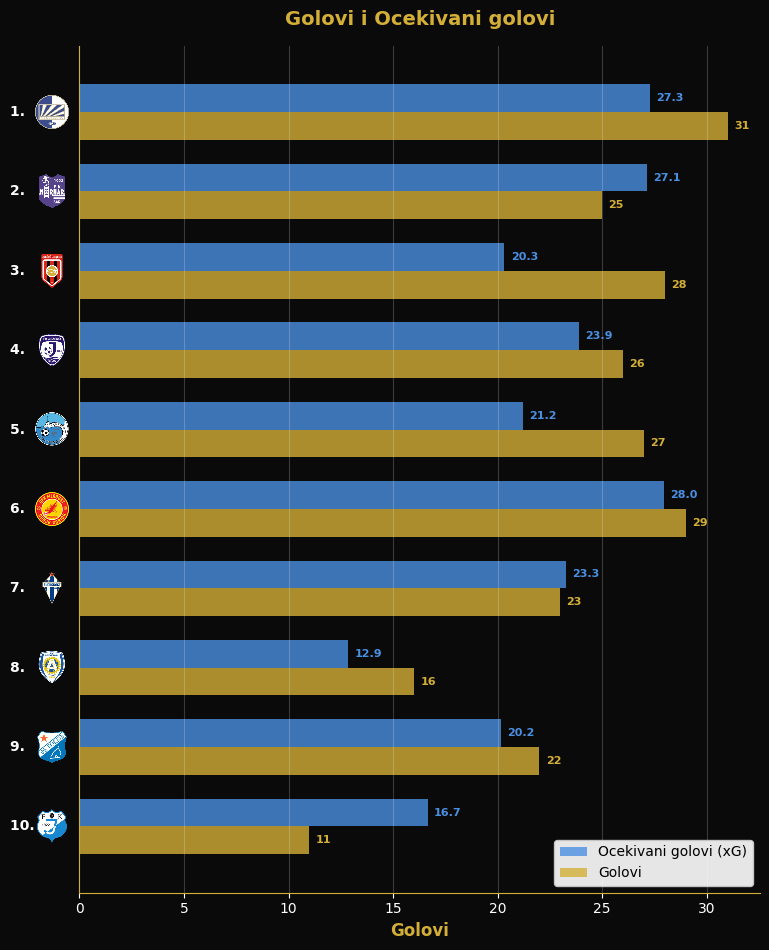

✅ Figure 2 saved to: ..\outputs\figures\team_xg_performance_difference.png


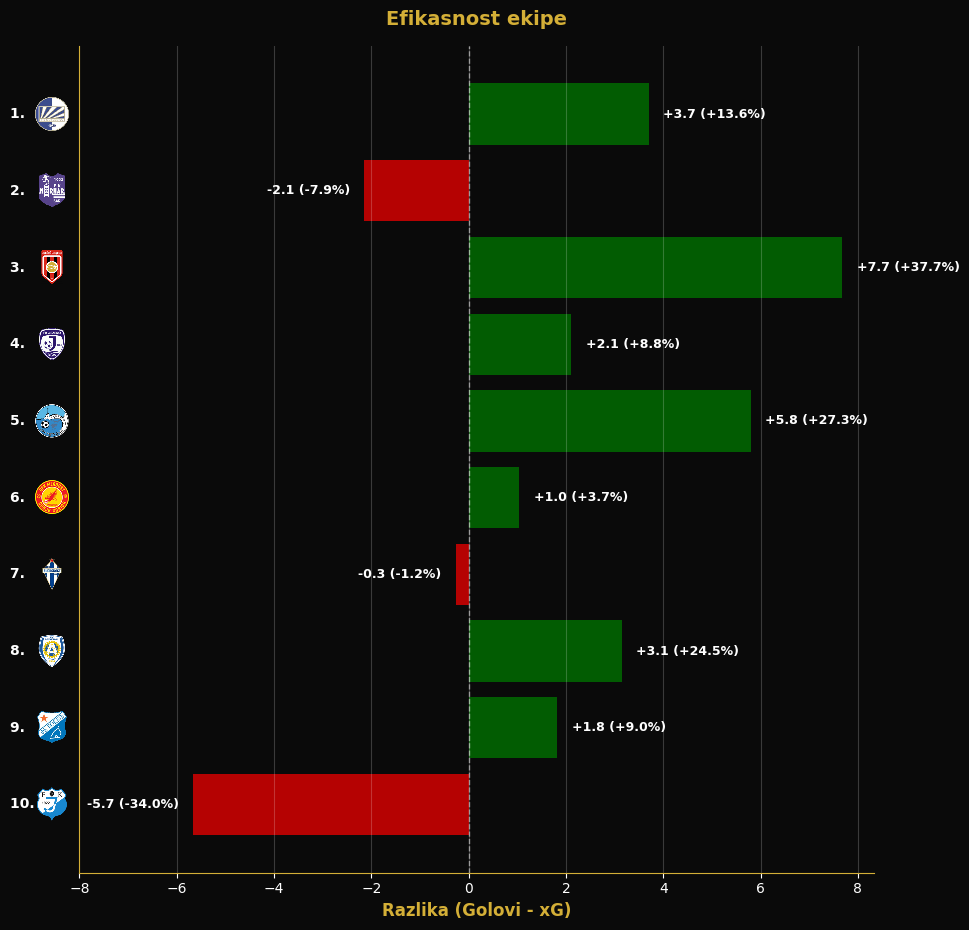

In [45]:
# =============================================================================
# Visualize Team Performance - Goals vs xG
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Use standings order when available, otherwise performance order
if 'team_stats_by_position' in globals() and not team_stats_by_position.empty:
    team_viz = team_stats_by_position.copy()
else:
    team_viz = team_stats_sorted.copy()

team_viz = team_viz.reset_index(drop=True)
x_pos = np.arange(len(team_viz))

# Create position labels
if 'Position' in team_viz.columns and team_viz['Position'].notna().any():
    fallback_positions = pd.Series(np.arange(1, len(team_viz) + 1), index=team_viz.index)
    pos_labels = team_viz['Position'].fillna(fallback_positions)
else:
    pos_labels = pd.Series(np.arange(1, len(team_viz) + 1), index=team_viz.index)
pos_labels = pos_labels.astype(int).astype(str) + '. '

# Load team logos
team_logos = {}
logos_dir = PROCESSED_DATA_DIR / 'team_logos'
if logos_dir.exists():
    for logo_file in logos_dir.glob('*.png'):
        try:
            tid = int(logo_file.stem)
            team_logos[tid] = mpimg.imread(logo_file)
        except Exception as e:
            print(f"⚠️ Could not load logo {logo_file}: {e}")

print(f"✅ Loaded {len(team_logos)} team logos")

def add_team_logos(ax, y_positions, team_ids, labels, x_offset_text=-50, x_offset_logo=-20, zoom=0.16):
    """Attach team position text and logos next to y-axis ticks."""
    if not team_logos:
        return
    
    for y, team_id, label in zip(y_positions, team_ids, labels):
        # Add position text
        ax.annotate(
            label, xy=(0, y), xycoords=('axes fraction', 'data'),
            xytext=(x_offset_text, 0), textcoords='offset points',
            ha='left', va='center', fontsize=10, color='white', fontweight='bold'
        )
        
        # Add team logo
        if pd.isna(team_id):
            continue
        try:
            tid = int(team_id)
        except (TypeError, ValueError):
            continue
        
        logo_img = team_logos.get(tid)
        if logo_img is None:
            continue
        
        imagebox = OffsetImage(logo_img, zoom=zoom)
        ab = AnnotationBbox(
            imagebox, (0, y), xycoords=('axes fraction', 'data'),
            xybox=(x_offset_logo, 0), boxcoords='offset points',
            frameon=False, pad=0
        )
        ax.add_artist(ab)

# =============================================================================
# FIGURE 1: Goals vs xG Comparison
# =============================================================================

fig1, ax1 = plt.subplots(figsize=(10, 10), facecolor='#0a0a0a')
bar_width = 0.35

# Create bars
bars1 = ax1.barh(x_pos - bar_width/2, team_viz['xG'], bar_width, 
                 label='Ocekivani golovi (xG)', color='#4a90e2', alpha=0.8)
bars2 = ax1.barh(x_pos + bar_width/2, team_viz['Goals'], bar_width, 
                 label='Golovi', color='#d4af37', alpha=0.8)

# Add value labels
for bar, val in zip(bars1, team_viz['xG']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}', ha='left', va='center', fontsize=8, 
             color='#4a90e2', fontweight='bold')

for bar, val in zip(bars2, team_viz['Goals']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{int(val)}', ha='left', va='center', fontsize=8, 
             color='#d4af37', fontweight='bold')

# Styling
ax1.set_yticks(x_pos)
ax1.set_yticklabels([''] * len(team_viz))
ax1.tick_params(axis='y', length=0)
ax1.set_xlabel('Golovi', fontsize=12, color='#d4af37', fontweight='bold')
ax1.set_title('Golovi i Ocekivani golovi', fontsize=14, color='#d4af37', fontweight='bold', pad=15)
ax1.legend(loc='lower right', framealpha=0.9)
ax1.set_facecolor('#0a0a0a')
ax1.grid(axis='x', alpha=0.2, color='white')
ax1.tick_params(axis='x', colors='white')
ax1.spines['bottom'].set_color('#d4af37')
ax1.spines['left'].set_color('#d4af37')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.invert_yaxis()

add_team_logos(ax1, x_pos, team_viz['team_id'], pos_labels)

plt.tight_layout(rect=[0.22, 0.02, 1, 0.98])

# Save
figures_dir = Path('..') / 'outputs' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
output_path = figures_dir / 'team_goals_vs_xg_comparison.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', 
            facecolor='#0a0a0a', edgecolor='none')
print(f'✅ Figure 1 saved to: {output_path}')
plt.show()

# =============================================================================
# FIGURE 2: Performance Difference
# =============================================================================

fig2, ax2 = plt.subplots(figsize=(10, 10), facecolor='#0a0a0a')

colors = ['green' if x > 0 else 'red' for x in team_viz['Diff']]
bars = ax2.barh(x_pos, team_viz['Diff'], color=colors, alpha=0.7)

# Add value labels
for bar, val, pct in zip(bars, team_viz['Diff'], team_viz['Diff_Pct']):
    width = bar.get_width()
    label_x = width + 0.3 if width > 0 else width - 0.3
    ha = 'left' if width > 0 else 'right'
    ax2.text(label_x, bar.get_y() + bar.get_height()/2, 
             f'{val:+.1f} ({pct:+.1f}%)', 
             ha=ha, va='center', fontsize=9, color='white', fontweight='bold')

# Styling
ax2.set_yticks(x_pos)
ax2.set_yticklabels([''] * len(team_viz))
ax2.tick_params(axis='y', length=0)
ax2.set_xlabel('Razlika (Golovi - xG)', fontsize=12, color='#d4af37', fontweight='bold')
ax2.set_title('Efikasnost ekipe', fontsize=14, color='#d4af37', fontweight='bold', pad=15)
ax2.axvline(x=0, color='white', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlim(left=-8, right=None)
ax2.set_facecolor('#0a0a0a')
ax2.grid(axis='x', alpha=0.2, color='white')
ax2.tick_params(axis='x', colors='white')
ax2.spines['bottom'].set_color('#d4af37')
ax2.spines['left'].set_color('#d4af37')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.invert_yaxis()

add_team_logos(ax2, x_pos, team_viz['team_id'], pos_labels)

plt.tight_layout(rect=[0.02, 0.04, 1, 0.98])

# Save
output_path = figures_dir / 'team_xg_performance_difference.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', 
            facecolor='#0a0a0a', edgecolor='none')
print(f'✅ Figure 2 saved to: {output_path}')
plt.show()